In [5]:
from tensorflow.keras import mixed_precision

# 1. Mixed Precision'ı Aktif Et
# Bu satır, uygun katmanları float16, hassas olması gerekenleri float32 yapar.
policy = mixed_precision.Policy('mixed_float16')
mixed_precision.set_global_policy(policy)

print('Compute dtype: %s' % policy.compute_dtype)
print('Variable dtype: %s' % policy.variable_dtype)

Compute dtype: float16
Variable dtype: float32


In [12]:

# ==========================================
# 4. ÇALIŞTIRMA VE EĞİTİM
# ==========================================
import gc
# Dosya yolu (Kendi yolunuzu buraya yazın)
# train_csv_path = "../data/signal//2026-01-22-fence-kagan-3clf_noise-7.5k/train.csv"
# Eğer variable olarak DataFrame varsa: train_csv_df
from pathlib import Path
import pandas as pd
from unsupervised_sequence import UnsupervisedSpatialSequence, build_channel_aware_autoencoder
# 1. Sequence Oluştur
train_csv = pd.read_csv(Path("../data/signal/2025-11-27_5clf_best_data/train.csv"))
train_seq = UnsupervisedSpatialSequence(train_csv, batch_size=64, window_size=20000)
# NOT: Window size 7500, 8'e bölünmez. Padding hatası almamak için 7504 yapıyoruz.
WINDOW_SIZE = 20000 
BATCH_SIZE = 16

# Sequence oluştur (DataFrame veya Path verebilirsin)
print("Veri yükleniyor...")
# train_csv_df değişkenin varsa buraya onu yaz, yoksa path stringi yaz.
train_seq = UnsupervisedSpatialSequence(train_csv, batch_size=BATCH_SIZE, window_size=WINDOW_SIZE)

# Modeli kur
print("Model kuruluyor...")
model, encoder = build_channel_aware_autoencoder(input_length=WINDOW_SIZE, 
                                                 num_channels=train_seq.num_unique_channels)

# Compile & Fit
model.compile(optimizer='adam', loss='mse')

print("Eğitim başlıyor...")
try:
    model.fit(train_seq, epochs=5) # Deneme için 5 epoch
except KeyboardInterrupt:
    print("\nEğitim kullanıcı tarafından durduruldu.")



Veri yükleniyor...
Model kuruluyor...
Eğitim başlıyor...
Epoch 1/5
4675/4675 [==============================] - 1518s 136ms/step - loss: 45809.3047
Epoch 2/5
4675/4675 [==============================] - 1907s 408ms/step - loss: 985.5140
Epoch 3/5
4675/4675 [==============================] - 598s 128ms/step - loss: 693.2142
Epoch 4/5
4675/4675 [==============================] - 598s 128ms/step - loss: 582.0938
Epoch 5/5
4675/4675 [==============================] - 591s 126ms/step - loss: 428.4348


In [9]:
# ==========================================
# 5. LATENT SPACE ÇIKARMA (RAM DOSTU YÖNTEM)
# ==========================================
print("Latent Feature'lar çıkarılıyor (Güvenli Mod)...")
import gc
from tqdm import tqdm
import numpy as np
latent_features_list = []
# Garbage collection
gc.collect()

# Manuel döngü ile tek tek tahmin alıp RAM'e çekiyoruz
for i in tqdm(range(len(train_seq))):
    x_batch, _ = train_seq[i]
    
    # Tahmin (GPU) -> (Batch, 128)
    batch_emb = encoder.predict_on_batch(x_batch)
    
    # Listeye ekle (CPU)
    latent_features_list.append(batch_emb)

# Birleştir
latent_features = np.concatenate(latent_features_list, axis=0)

print(f"✅ İŞLEM TAMAM! Latent Space Boyutu: {latent_features.shape}")
print("Örnek vektör:", latent_features[0][:5])

Latent Feature'lar çıkarılıyor (Güvenli Mod)...


100%|██████████| 4816/4816 [03:10<00:00, 25.28it/s]

✅ İŞLEM TAMAM! Latent Space Boyutu: (77043, 128)
Örnek vektör: [ 7.66   2.38  21.42   0.     2.158]


T-SNE hesaplanıyor (Biraz sürebilir)...


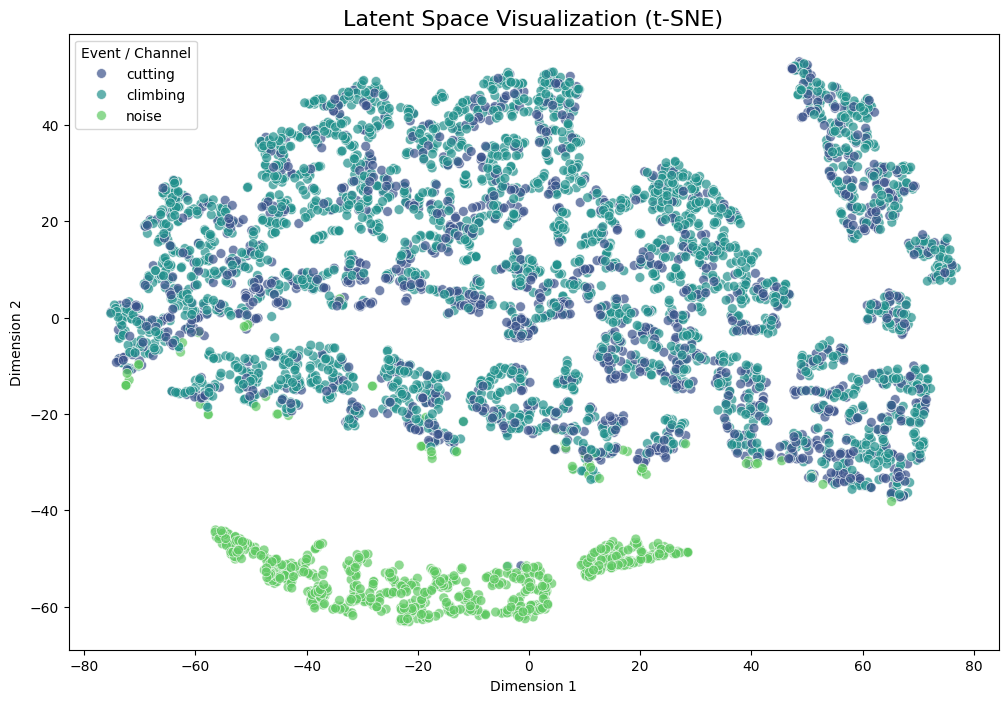

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

# 1. Veri Hazırlığı
# Tüm veri çok büyük olduğu için (77k), görselleştirme için rastgele 5000 örnek seçelim
# Bu hem hızı artırır hem de grafiğin okunabilirliğini sağlar.
import numpy as np
indices = np.random.choice(len(latent_features), 5000, replace=False)

subset_features = latent_features[indices]
subset_labels = train_seq.data.iloc[indices]['event'].values # Varsa etiketler
# Etiket yoksa 'channel' bilgisini de kullanabilirsiniz:
# subset_labels = train_seq.data.iloc[indices]['channel'].values 

print("T-SNE hesaplanıyor (Biraz sürebilir)...")
# 2. Boyut İndirgeme (t-SNE)
# 128 boyutu -> 2 boyuta indiriyoruz
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
tsne_results = tsne.fit_transform(subset_features)

# 3. Görselleştirme
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x=tsne_results[:, 0], 
    y=tsne_results[:, 1],
    hue=subset_labels, # Renklendirme (Sınıf veya Kanal ID)
    palette="viridis",
    s=50,
    alpha=0.7
)
plt.title("Latent Space Visualization (t-SNE)", fontsize=16)
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.legend(title="Event / Channel")
plt.show()